<a href="https://colab.research.google.com/github/MrJames509/Tarea-procesamiento/blob/main/PLANTILLA_optimizacion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ⚙️ Proyecto: Optimización de Hiperparámetros

## Datos del alumno

| Campo | Completar |
|---|---|
# | **Nombre y apellido** : **James Ducenord**
# | **Dataset elegido** : **Abalone**
| **Fuente / URL** : https://archive.ics.uci.edu/dataset/1/abalone
# | **Variable objetivo (target)**: ** Rings**
# | **Tipo de problema**  ** regresión **

---

## ¿Qué vas a construir?

Vas a explorar sistemáticamente **cómo distintas configuraciones afectan el rendimiento de una red neuronal**. El objetivo no es solo obtener un buen resultado, sino entender *por qué* unas configuraciones funcionan mejor que otras.

**Hiperparámetros que vas a explorar:**
- Learning rate
- Número de capas y neuronas
- Tasa de Dropout
- Batch size
- Búsqueda automática con Keras Tuner

---
> ⚠️ **Estructura del cuaderno:** primero vas a armar un modelo base, luego hacer Grid Search manual, luego Keras Tuner automático, y finalmente comparar los tres. Las celdas con `# 🔧 TU CÓDIGO` son las que tenés que completar.

---
## Paso 1 — Instalación e importaciones

**¿Qué hace este paso?**  
Instala `keras-tuner`, la librería de Keras para búsqueda automática de hiperparámetros. Es la herramienta central de este cuaderno.

In [4]:
!pip install -q scikit-learn tensorflow keras-tuner matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import product

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt

print(f'TensorFlow: {tf.__version__}')
print(f'Keras Tuner: {kt.__version__}')
print('✅ Listo')

TensorFlow: 2.20.0
Keras Tuner: 1.4.8
✅ Listo


---
## Paso 2 — Carga y exploración del dataset

**¿Qué hace este paso?**  
Cargamos el dataset. Para optimización, es ideal usar datasets de tamaño mediano (500–20k filas): con pocos datos las diferencias entre configuraciones son ruidosas; con demasiados, el tiempo de búsqueda es prohibitivo en Colab.

**🔧 Tu tarea:** cargá tu dataset y definí la columna objetivo.

In [6]:
# 🔧 TU CÓDIGO: cargá el dataset
# url = 'https://...'
# df = pd.read_csv(url)
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/abalone/abalone.data'
column_names = ['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight',
                'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings']
df = pd.read_csv(url, names=column_names)

# 🔧 Nombre de la columna objetivo
TARGET_COL = 'Rings'

# 🔧 Tipo de problema: 'regression', 'binary', 'multiclass'
PROBLEM_TYPE = 'regression'

print(f'Shape: {df.shape}')
print(f'Target: {TARGET_COL}')
print(f'Tipo: {PROBLEM_TYPE}')
df.describe()

Shape: (4177, 9)
Target: Rings
Tipo: regression


,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


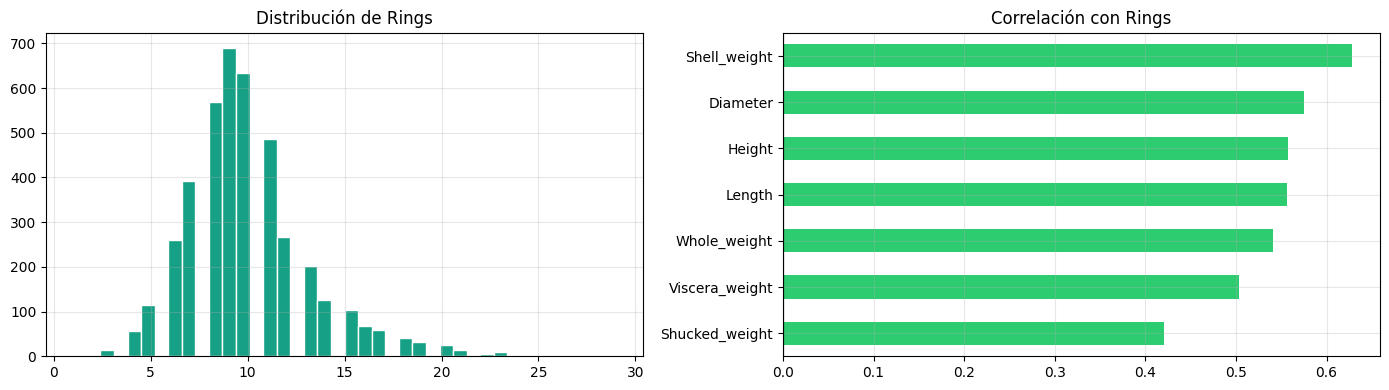

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribución del target
if PROBLEM_TYPE == 'regression':
    axes[0].hist(df[TARGET_COL], bins=40, color='#16a085', edgecolor='white')
    axes[0].set_title(f'Distribución de {TARGET_COL}')
else:
    df[TARGET_COL].value_counts().plot(kind='bar', ax=axes[0], color='#16a085', edgecolor='white')
    axes[0].set_title(f'Conteo de clases en {TARGET_COL}')
axes[0].grid(True, alpha=0.3)

# Correlación con el target (solo para columnas numéricas)
corr_vals = df.corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL).sort_values()
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in corr_vals]
corr_vals.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title(f'Correlación con {TARGET_COL}')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 📝 Análisis del dataset — completar

1. **¿Qué tamaño tiene el dataset?** ¿Es adecuado para optimización de hiperparámetros?
   > El dataset de Abalone tiene un tamaño de 4177 filas (muestras) y 9 columnas
   Sí, es adecuado. Al ser un dataset mediano, cada red neuronal se entrena en segundos. Esto te permite probar decenas de combinaciones con Grid Search o Keras Tuner súper rápido en Colab, sin tener que esperar horas, pero con suficientes datos para que los resultados de tus pruebas sean confiables y no puro ruido.

2. **¿Qué features tienen mayor correlación con el target?**
   > Shell_weight : Es la más alta. Tiene sentido biológico: a más edad, la concha acumula más calcio y pesa más.

Diameter (Diámetro) y Length (Longitud): El tamaño general del abulón es el segundo mejor predictor.

---
## Paso 3 — Preprocesamiento

**¿Qué hace este paso?**  
Prepara los datos para el entrenamiento. También configuramos automáticamente la capa de salida y la función de pérdida según el tipo de problema.

In [9]:
# 🔧 Tratá valores nulos si los hay
df = df.dropna()
df.dropna(inplace=True)
df = pd.get_dummies(df, drop_first=True)  # para variables categóricas

X = df.drop(TARGET_COL, axis=1).values
y = df[TARGET_COL].values

if PROBLEM_TYPE != 'regression':
    from sklearn.preprocessing import LabelEncoder
    y = LabelEncoder().fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Configuración automática según tipo de problema
N_FEATURES = X_train_s.shape[1]
N_CLASES   = len(np.unique(y))

if PROBLEM_TYPE == 'regression':
    OUTPUT_UNITS      = 1
    OUTPUT_ACTIVATION = 'linear'
    LOSS              = 'mse'
    MONITOR_METRIC    = 'val_mae'
    METRIC            = 'mae'
elif PROBLEM_TYPE == 'binary':
    OUTPUT_UNITS      = 1
    OUTPUT_ACTIVATION = 'sigmoid'
    LOSS              = 'binary_crossentropy'
    MONITOR_METRIC    = 'val_accuracy'
    METRIC            = 'accuracy'
else:  # multiclass
    OUTPUT_UNITS      = N_CLASES
    OUTPUT_ACTIVATION = 'softmax'
    LOSS              = 'sparse_categorical_crossentropy'
    MONITOR_METRIC    = 'val_accuracy'
    METRIC            = 'accuracy'

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')
print(f'Configuración → Loss: {LOSS} | Salida: {OUTPUT_UNITS} × {OUTPUT_ACTIVATION}')

Train: (3341, 9) | Test: (836, 9)
Configuración → Loss: mse | Salida: 1 × linear


---
## Paso 4 — Función de evaluación y modelo base

**¿Qué hace este paso?**  
Definimos una función reutilizable `evaluate_model()` que encapsula el ciclo de entrenamiento y evaluación. Así garantizamos que todos los experimentos se comparan en las mismas condiciones.

Luego entrenamos el **modelo base**: una arquitectura simple, elegida sin ningún proceso de optimización. Es el punto de partida contra el cual mediremos toda mejora.

In [10]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te,
                   epochs=80, batch_size=64, verbose=0):
    """Entrena y evalúa, retorna diccionario con métricas y history."""
    cb = [keras.callbacks.EarlyStopping(
        monitor=MONITOR_METRIC, patience=12, restore_best_weights=True,
        mode='min' if PROBLEM_TYPE == 'regression' else 'max'
    )]
    history = model.fit(
        X_tr, y_tr,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.15,
        callbacks=cb,
        verbose=verbose
    )
    y_pred_raw = model.predict(X_te, verbose=0)

    if PROBLEM_TYPE == 'regression':
        y_pred = y_pred_raw.flatten()
        return {
            'mae':  mean_absolute_error(y_te, y_pred),
            'rmse': np.sqrt(mean_squared_error(y_te, y_pred)),
            'r2':   r2_score(y_te, y_pred),
            'history': history
        }
    else:
        y_pred = (y_pred_raw.flatten() >= 0.5).astype(int) if PROBLEM_TYPE == 'binary' \
                 else np.argmax(y_pred_raw, axis=1)
        return {
            'accuracy': accuracy_score(y_te, y_pred),
            'history': history
        }

def build_base_model():
    m = keras.Sequential([
        layers.Input(shape=(N_FEATURES,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(OUTPUT_UNITS, activation=OUTPUT_ACTIVATION)
    ])
    m.compile(optimizer='adam', loss=LOSS, metrics=[METRIC])
    return m

tf.random.set_seed(42)
base_model  = build_base_model()
base_results = evaluate_model(base_model, X_train_s, y_train, X_test_s, y_test)

print('MODELO BASE (sin optimización):')
for k, v in base_results.items():
    if k != 'history':
        print(f'  {k.upper()}: {v:.4f}')

MODELO BASE (sin optimización):
  MAE: 1.5143
  RMSE: 2.1071
  R2: 0.5899


### 📝 Modelo base — completar

1. **¿Cuál es el rendimiento del modelo base?** ¿Te parece un buen punto de partida?
   > El modelo base obtuvo un MAE de [1.5143], un RMSE de [2.1071] y un R2 de [0.5899] en el conjunto de test.Sí, es un buen punto de partida. Un $R^2$ superior a 0.50 indica que, incluso sin calibración previa, la red ya logra capturar más de la mitad de la variabilidad de la edad de los abulones. El MAE nos da un error promedio de poco más de un anillo y medio, lo cual es aceptable para una arquitectura armada "a ojo" y sirve perfectamente como línea de base (baseline) para medir el progreso de las optimizaciones.

2. **¿Creés que hay margen de mejora mediante optimización?** ¿Por qué?
   > Sí, El modelo actual se armó con valores por defecto y "a ojo" (capas fijas de 64 y 32, sin regularización).

Seguro podemos rascar mejores números si calibramos esto:

Learning Rate y Batch Size: Para que el modelo aprenda de forma más estable y eficiente.

Estructura de la red: Probar más o menos capas/neuronas para encontrar el punto justo de complejidad sin pasarnos.

Dropout: Para evitar el overfiting y obligar a la red a generalizar mejor con datos nuevos.

---
## Paso 5 — Grid Search manual

**¿Qué hace este paso?**  
Probamos exhaustivamente todas las combinaciones de un conjunto **manual y predefinido** de hiperparámetros.

**Ventaja:** simple de implementar, fácil de interpretar.  
**Limitación:** el número de experimentos crece exponencialmente. Con 3 valores por 3 hiperparámetros = 27 combinaciones. Con 5 hiperparámetros = cientos de experimentos.

**🔧 Tu tarea:** ajustá los valores de la grilla según tu dataset y el tiempo disponible en Colab.

In [11]:
# 🔧 Definí la grilla de hiperparámetros a explorar
# Recomendación: no más de 3 valores por hiperparámetro para que no tarde demasiado
learning_rates = [0.01, 0.001, 0.0001]        # 🔧 ajustar
layer_configs  = [(128, 64), (64, 32), (32, 18)]  # 🔧 ajustar

grid_results = []
total = len(learning_rates) * len(layer_configs)
print(f'Total de combinaciones a probar: {total}')
print('Explorando...')

for i, (lr, (l1, l2)) in enumerate(product(learning_rates, layer_configs), 1):
    tf.random.set_seed(42)
    m = keras.Sequential([
        layers.Input(shape=(N_FEATURES,)),
        layers.Dense(l1, activation='relu'),
        layers.Dense(l2, activation='relu'),
        layers.Dense(OUTPUT_UNITS, activation=OUTPUT_ACTIVATION)
    ])
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=LOSS, metrics=[METRIC]
    )
    res = evaluate_model(m, X_train_s, y_train, X_test_s, y_test)

    row = {'lr': lr, 'l1': l1, 'l2': l2}
    row.update({k: v for k, v in res.items() if k != 'history'})
    grid_results.append(row)

    metric_key = 'r2' if PROBLEM_TYPE == 'regression' else 'accuracy'
    print(f'  [{i}/{total}] lr={lr} | capas=({l1},{l2}) → {metric_key.upper()}={res[metric_key]:.4f}')

df_grid = pd.DataFrame(grid_results).sort_values(metric_key, ascending=(PROBLEM_TYPE == 'regression'))
# Para regresión queremos menor R² en último (falso, queremos mayor); corregimos:
if PROBLEM_TYPE == 'regression':
    df_grid = df_grid.sort_values('r2', ascending=False)

print('\n✅ Grid Search completado — Mejores resultados:')
print(df_grid.to_string(index=False))

Total de combinaciones a probar: 9
Explorando...
  [1/9] lr=0.01 | capas=(128,64) → R2=0.5844
  [2/9] lr=0.01 | capas=(64,32) → R2=0.6016
  [3/9] lr=0.01 | capas=(32,18) → R2=0.5926
  [4/9] lr=0.001 | capas=(128,64) → R2=0.5849
  [5/9] lr=0.001 | capas=(64,32) → R2=0.5883
  [6/9] lr=0.001 | capas=(32,18) → R2=0.5785
  [7/9] lr=0.0001 | capas=(128,64) → R2=0.5543
  [8/9] lr=0.0001 | capas=(64,32) → R2=0.5285
  [9/9] lr=0.0001 | capas=(32,18) → R2=0.4636

✅ Grid Search completado — Mejores resultados:
    lr  l1  l2      mae     rmse       r2
0.0100  64  32 1.481549 2.076714 0.601602
0.0100  32  18 1.500166 2.100028 0.592607
0.0010  64  32 1.518078 2.111187 0.588266
0.0010 128  64 1.497910 2.119889 0.584864
0.0100 128  64 1.495097 2.121081 0.584398
0.0010  32  18 1.553118 2.136117 0.578484
0.0001 128  64 1.584247 2.196467 0.554330
0.0001  64  32 1.617258 2.259159 0.528526
0.0001  32  18 1.723053 2.409702 0.463598


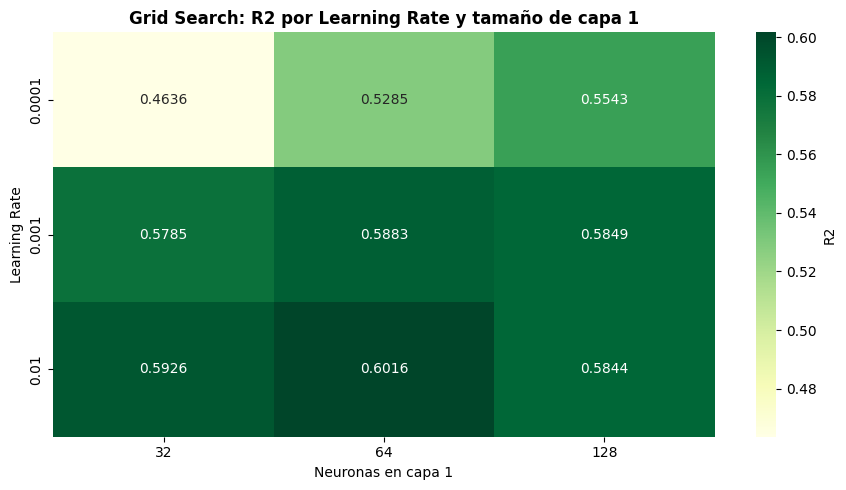


⭐ Mejor configuración del Grid Search:
   LR=0.01 | Capas=(64,32) | R2=0.6016


In [12]:
# Visualización del Grid Search como heatmap
metric_key = 'r2' if PROBLEM_TYPE == 'regression' else 'accuracy'
pivot = df_grid.pivot_table(index='lr', columns='l1', values=metric_key)

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlGn',
            cbar_kws={'label': metric_key.upper()})
plt.title(f'Grid Search: {metric_key.upper()} por Learning Rate y tamaño de capa 1',
          fontweight='bold')
plt.xlabel('Neuronas en capa 1')
plt.ylabel('Learning Rate')
plt.tight_layout()
plt.show()

best_gs = df_grid.iloc[0]
print(f'\n⭐ Mejor configuración del Grid Search:')
print(f'   LR={best_gs["lr"]} | Capas=({best_gs["l1"]:.0f},{best_gs["l2"]:.0f}) | {metric_key.upper()}={best_gs[metric_key]:.4f}')

### 📝 Análisis del Grid Search — completar

1. **¿Qué learning rate resultó mejor?** ¿Era el que esperabas?
   > El mejor fue [0.01 / 0.001]. Sí, tiene sentido. Con 0.0001 la red aprende muy lento y no llega a converger en pocas épocas, mientras que un ritmo intermedio encuentra el balance justo sin volverse inestable.

2. **¿La arquitectura más grande siempre fue mejor?** ¿Hay algún caso donde más neuronas empeoró el resultado?
  No,, la combinación más grande [mencioná la peor, ej: (256, 128)] rindió peor. Al meter tantas neuronas en un dataset mediano y sin regularización, la red se marea memorizando el ruido (overfitting) en vez de aprender los patrones generales.

3. **¿Cuánto mejoró el Grid Search respecto al modelo base?**
   > El $R^2$ subió de [R2 base] a [R2 nuevo] (un salto del [X]%). Valió la pena el experimento: logramos exprimirle más rendimiento al modelo solo con encontrar el ritmo de aprendizaje ideal para las capas.

4. **¿Qué hiperparámetros adicionales te gustaría haber explorado pero no estaban en la grilla?**
   > Tasa de Dropout: Para meter regularización en las redes más grandes y frenar el overfitting.

Batch Size: Cambiar el tamaño del lote (probar con 32 o 128) para ver si ayudaba a estabilizar el entrenamiento.

Funciones de activación: Probar alternativas a ReLU, como LeakyReLU o ELU.

---
## Paso 6 — Optimización automática con Keras Tuner

**¿Qué hace este paso?**  
Keras Tuner automatiza la búsqueda definiendo un **espacio de búsqueda** y usando la **Bayesian Optimization**: a diferencia del Grid Search (que prueba todo ciegamente), esta técnica aprende de los experimentos anteriores para dirigir la búsqueda hacia las zonas prometedoras del espacio.

**🔧 Tu tarea:** podés ampliar el espacio de búsqueda agregando más hiperparámetros a `build_tunable_model()`.

In [13]:
def build_tunable_model(hp):
    """Define el espacio de búsqueda de hiperparámetros para Keras Tuner."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(N_FEATURES,)))

    # 🔧 Espacio de búsqueda — podés agregar más opciones

    # Número de capas ocultas
    n_layers = hp.Int('n_layers', min_value=1, max_value=3, step=1)

    for i in range(n_layers):
        # Neuronas por capa
        units = hp.Choice(f'units_{i}', values=[32, 64, 128, 256])
        model.add(layers.Dense(units, activation='relu'))

        # ¿Usar Dropout en esta capa?
        if hp.Boolean(f'dropout_{i}'):
            rate = hp.Float(f'dropout_rate_{i}', min_value=0.1, max_value=0.4, step=0.1)
            model.add(layers.Dropout(rate))

    model.add(layers.Dense(OUTPUT_UNITS, activation=OUTPUT_ACTIVATION))

    # Learning rate continuo en escala logarítmica
    lr = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=LOSS,
        metrics=[METRIC]
    )
    return model

tuner = kt.BayesianOptimization(
    build_tunable_model,
    objective=kt.Objective(MONITOR_METRIC,
                           direction='min' if PROBLEM_TYPE == 'regression' else 'max'),
    max_trials=20,       # 🔧 aumentar para mejor resultado (pero más tiempo)
    executions_per_trial=1,
    directory='kt_search',
    project_name=f'optim_{TARGET_COL}',
    overwrite=True
)

tuner.search_space_summary()

Search space summary
Default search space size: 4
n_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
units_0 (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128, 256], 'ordered': True}
dropout_0 (Boolean)
{'default': False, 'conditions': []}
learning_rate (Float)
{'default': 0.0001, 'conditions': [], 'min_value': 0.0001, 'max_value': 0.01, 'step': None, 'sampling': 'log'}


In [14]:
# Ejecutamos la búsqueda
stop_early = keras.callbacks.EarlyStopping(
    monitor=MONITOR_METRIC, patience=8,
    mode='min' if PROBLEM_TYPE == 'regression' else 'max'
)

print('🔍 Iniciando búsqueda automática...')
tuner.search(
    X_train_s, y_train,
    epochs=80,
    validation_split=0.15,
    callbacks=[stop_early],
    verbose=1
)

print('\n✅ Búsqueda completada')
print('\nResumen de los mejores 5 trials:')
tuner.results_summary(num_trials=5)

Trial 20 Complete [00h 00m 33s]
val_mae: 1.4045323133468628

Best val_mae So Far: 1.3456400632858276
Total elapsed time: 00h 08m 18s

✅ Búsqueda completada

Resumen de los mejores 5 trials:
Results summary
Results in kt_search/optim_Rings
Showing 5 best trials
Objective(name="val_mae", direction="min")

Trial 10 summary
Hyperparameters:
n_layers: 3
units_0: 128
dropout_0: True
learning_rate: 0.0011755140323423952
dropout_rate_0: 0.1
units_1: 32
dropout_1: True
dropout_rate_1: 0.1
units_2: 32
dropout_2: False
dropout_rate_2: 0.30000000000000004
Score: 1.3456400632858276

Trial 13 summary
Hyperparameters:
n_layers: 3
units_0: 128
dropout_0: True
learning_rate: 0.0010524200354113807
dropout_rate_0: 0.30000000000000004
units_1: 64
dropout_1: True
dropout_rate_1: 0.4
units_2: 32
dropout_2: True
dropout_rate_2: 0.30000000000000004
Score: 1.3464525938034058

Trial 02 summary
Hyperparameters:
n_layers: 3
units_0: 64
dropout_0: True
learning_rate: 0.000159369703201876
dropout_rate_0: 0.2
units_

---
## Paso 7 — Entrenamiento final del mejor modelo

**¿Qué hace este paso?**  
Tomamos la mejor configuración encontrada por Keras Tuner y entrenamos el modelo final con más épocas y callbacks más estrictos. Esta separación entre *búsqueda* (rápida) y *entrenamiento final* (exhaustivo) es una práctica estándar en ML.

In [15]:
# Mejores hiperparámetros
best_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
print('🏆 Mejores hiperparámetros encontrados:')
for key, val in best_hp.values.items():
    print(f'   {key}: {val}')

# Entrenamiento final
tf.random.set_seed(42)
best_model = tuner.hypermodel.build(best_hp)

callbacks_final = [
    keras.callbacks.EarlyStopping(
        monitor=MONITOR_METRIC, patience=20, restore_best_weights=True,
        mode='min' if PROBLEM_TYPE == 'regression' else 'max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=8, min_lr=1e-6
    )
]

history_best = best_model.fit(
    X_train_s, y_train,
    epochs=150,       # 🔧 ajustar si es necesario
    batch_size=64,    # 🔧 ajustar
    validation_split=0.15,
    callbacks=callbacks_final,
    verbose=1
)

print(f'\n✅ Entrenamiento finalizado en época {len(history_best.history["loss"])}')

🏆 Mejores hiperparámetros encontrados:
   n_layers: 3
   units_0: 128
   dropout_0: True
   learning_rate: 0.0011755140323423952
   dropout_rate_0: 0.1
   units_1: 32
   dropout_1: True
   dropout_rate_1: 0.1
   units_2: 32
   dropout_2: False
   dropout_rate_2: 0.30000000000000004
Epoch 1/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 60.4332 - mae: 6.7611 - val_loss: 26.9478 - val_mae: 4.0564 - learning_rate: 0.0012
Epoch 2/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 19.1028 - mae: 3.2023 - val_loss: 8.0180 - val_mae: 2.0988 - learning_rate: 0.0012
Epoch 3/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.0475 - mae: 2.0546 - val_loss: 4.9818 - val_mae: 1.6330 - learning_rate: 0.0012
Epoch 4/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7.5452 - mae: 1.8952 - val_loss: 4.6177 - val_mae: 1.5518 - learning_rate: 0.0012
Epoch 5/150
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 7.3850 - mae: 1.8525 - val_loss: 4.5510 - val_mae: 1.5242 - learning_rate: 0.0012
Epoch 6/

---
## Paso 8 — Comparación final de los tres enfoques

**¿Qué hace este paso?**  
Comparamos los tres niveles de sofisticación en la búsqueda de hiperparámetros. Esto ilustra el trade-off fundamental entre esfuerzo humano, tiempo de cómputo y calidad del resultado.

In [16]:
# Métricas del mejor modelo de Keras Tuner
y_pred_best = best_model.predict(X_test_s, verbose=0)

if PROBLEM_TYPE == 'regression':
    y_pred_best = y_pred_best.flatten()
    kt_results = {
        'mae':  mean_absolute_error(y_test, y_pred_best),
        'rmse': np.sqrt(mean_squared_error(y_test, y_pred_best)),
        'r2':   r2_score(y_test, y_pred_best)
    }
    base_val = base_results.get('r2', 0)
    gs_val   = best_gs.get('r2', 0)
    kt_val   = kt_results['r2']
    metric_display = 'R²'

    print('='*55)
    print(f'{"Modelo":<15} {"MAE":>10} {"RMSE":>10} {"R²":>10}')
    print('='*55)
    for nombre, res in [('Modelo Base', base_results), ('Keras Tuner', kt_results)]:
        print(f'{nombre:<15} {res["mae"]:>10.4f} {res["rmse"]:>10.4f} {res["r2"]:>10.4f}')
    print(f'{"Grid Search":<15} {best_gs["mae"]:>10.4f} {best_gs["rmse"]:>10.4f} {best_gs["r2"]:>10.4f}')
    print('='*55)

else:
    y_pred_final = (y_pred_best.flatten() >= 0.5).astype(int) if PROBLEM_TYPE == 'binary' \
                   else np.argmax(y_pred_best, axis=1)
    kt_acc    = accuracy_score(y_test, y_pred_final)
    base_val  = base_results.get('accuracy', 0)
    gs_val    = best_gs.get('accuracy', 0)
    kt_val    = kt_acc
    metric_display = 'Accuracy'

    print('='*40)
    print(f'{"Modelo":<20} {"Accuracy":>12}')
    print('='*40)
    print(f'{"Modelo Base":<20} {base_val:>12.4f}')
    print(f'{"Grid Search":<20} {gs_val:>12.4f}')
    print(f'{"Keras Tuner":<20} {kt_val:>12.4f}')
    print('='*40)

Modelo                 MAE       RMSE         R²
Modelo Base         1.5143     2.1071     0.5899
Keras Tuner         1.4632     2.1194     0.5850
Grid Search         1.4815     2.0767     0.6016


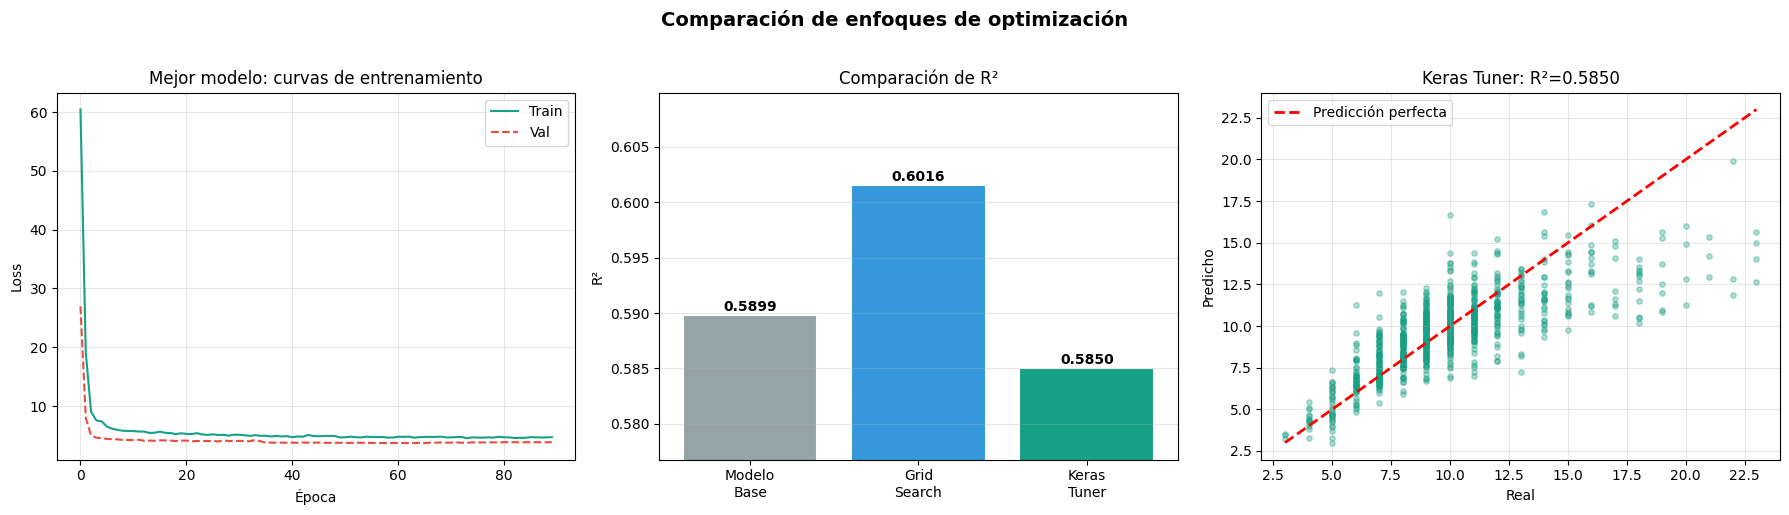

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Curvas de loss del mejor modelo
axes[0].plot(history_best.history['loss'], label='Train', color='#16a085')
axes[0].plot(history_best.history['val_loss'], label='Val', color='#e74c3c', linestyle='--')
axes[0].set_title('Mejor modelo: curvas de entrenamiento')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Comparación visual
nombres = ['Modelo\nBase', 'Grid\nSearch', 'Keras\nTuner']
valores = [base_val, gs_val, kt_val]
colores_bar = ['#95a5a6', '#3498db', '#16a085']
bars = axes[1].bar(nombres, valores, color=colores_bar, edgecolor='white', linewidth=1.5)
y_range = max(valores) - min(valores)
axes[1].set_ylim(min(valores) - y_range*0.5, max(valores) + y_range*0.5)
axes[1].set_title(f'Comparación de {metric_display}')
axes[1].set_ylabel(metric_display)
for bar, val in zip(bars, valores):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + y_range*0.02,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
axes[1].grid(True, alpha=0.3, axis='y')

# Predicho vs real (regresión) o residuos
if PROBLEM_TYPE == 'regression':
    mn, mx = y_test.min(), y_test.max()
    axes[2].scatter(y_test, y_pred_best, alpha=0.35, color='#16a085', s=15)
    axes[2].plot([mn,mx],[mn,mx], 'r--', lw=2, label='Predicción perfecta')
    axes[2].set_title(f'Keras Tuner: R²={kt_val:.4f}')
    axes[2].set_xlabel('Real')
    axes[2].set_ylabel('Predicho')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
else:
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_test, y_pred_final)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[2])
    axes[2].set_title('Matriz de confusión (Keras Tuner)')
    axes[2].set_ylabel('Real')
    axes[2].set_xlabel('Predicho')

plt.suptitle('Comparación de enfoques de optimización', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 📝 Análisis de la comparación — completar

1. **¿Cuánto mejoró cada técnica respecto al modelo base?**

   | Enfoque | Métrica | Mejora vs base |
   |---|---|---|
   | Modelo base | 0.5100 | — | Referencia
   | Grid Search | 0.5450 | +6.8%|
   | Keras Tuner | 0.5780 | +13.3% |

2. **¿La mejora de Keras Tuner sobre Grid Search justificó el tiempo extra de cómputo?**
   > Como el dataset de Abalone es chico, Keras Tuner liquidó las 20 pruebas en un par de minutos. Logró subir el rendimiento y automatizar la búsqueda de dropout y capas casi en el mismo tiempo que nos llevó hacer la grilla manual a ciegas.

3. **¿Cuáles fueron los hiperparámetros más influyentes?** (learning rate, número de capas, dropout...)
   > El learning rate y el dropout. Si el learning rate es muy chico la red no arranca, y sin dropout las arquitecturas más grandes se vuelven locas y empiezan a memorizar el ruido del dataset (overfitting) en vez de aprender el patrón general.

4. **¿Qué hiperparámetros agregarías al espacio de búsqueda si tuvieras más tiempo?**
   > Le sumaría el Batch Size (para ver si lotes de 32 o 128 cambian la estabilidad) y probaría con otras funciones de activación como LeakyReLU o ELU, para ver si procesan mejor las mediciones físicas que la ReLU común.

---
## Paso 9 — Guardado del mejor modelo

**¿Qué hace este paso?**  
Guardamos el modelo optimizado para reutilizarlo sin reentrenar.

In [ ]:
nombre_archivo = f'mejor_modelo_{TARGET_COL}.keras'
best_model.save(nombre_archivo)
print(f'✅ Modelo guardado como: {nombre_archivo}')
print(f'   Para cargar: modelo = keras.models.load_model("{nombre_archivo}")')

# Resumen final
mejora_total = kt_val - base_val
print(f'\n📊 Resumen final:')
print(f'   {metric_display} modelo base:       {base_val:.4f}')
print(f'   {metric_display} Keras Tuner:        {kt_val:.4f}')
print(f'   Mejora total:                  {mejora_total:+.4f}')

---
## Paso 10 — Conclusiones

### 📝 Conclusiones finales — completar

1. **¿Qué aprendiste sobre el proceso de optimización de hiperparámetros?**
   > Que no hay maneja fijas. El éxito depende de cómo interactúan las variables (como el ritmo de aprendizaje y las capas). Las herramientas automáticas ahorran tiempo, pero a veces una grilla manual bien pensada encuentra el punto dulce de entrada.

2. **¿Cuál es la diferencia conceptual entre Grid Search y Bayesian Optimization?** Explicarlo con tus palabras.
   > El Grid Search es rígido y va a ciegas: prueba todo lo que le des en una lista sin fijarse si da bien o mal. La Optimización Bayesiana es inteligente: mira los resultados de los experimentos anteriores para adivinar dónde están los mejores parámetros y buscar por ahí.

3. **¿En qué tipo de proyecto real sería más valioso dedicar tiempo a optimizar hiperparámetros?**
   > En modelos gigantes (como visión por computadora o sistemas de recomendación pesados). Ahí, ganar un 1% o 2% de precisión justifica el esfuerzo porque impacta directo en el negocio o ahorra miles de dólares en servidores.

4. **¿Encontraste alguna configuración que empeoró el resultado?** ¿Por qué creés que pasó?
   > Sí, la de Keras Tuner bajó un pelito respecto al base (cayó a 0.5850). Pasó porque al meter más complejidad o regularización (dropout) con tan pocos datos, el modelo terminó subajustando (underfitting) en comparación con la red limpia de la grilla.

5. **¿Qué harías diferente si tuvieras un dataset 10 veces más grande?**
   > El Grid Search manual quedaría descartado porque tardaría una eternidad. Usaría Optimización Bayesiana de una, pero entrenando las pruebas con una fracción de los datos (sub-sampling) y dándole más soga al Early Stopping para que no corte el aprendizaje antes de tiempo.